In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [21]:
class LinearRegression():
    def __init__(self, x, y, epoch, learning_constant = 0.00001):
        self.x = x
        self.y = y
        self.points = x.size
        self.learning_constant = learning_constant
        self.weight = 0
        self.bias = 1
        self.cost = None
        self.epoch = epoch

    # The model aims to obtain a weight and a bias such that ther is no change in cost
    def cost_error(self):
        error = (self.y - (self.weight * self.x + self.bias)) **2 # Formula to calculate the cost
        total = np.sum(error)

        # Returns the cost as per the formula for the mean squared error (MSE) - the average squared distance between predicted values and actual values
        return total / self.points

    def train(self):
        print(f"Initial weight: {self.weight}, initial bias {self.bias}")
        for i in range(self.epoch):
            self.update_weights()

        self.cost = self.cost_error()
        print(f"Final weight: {self.weight}, final bias: {self.bias}")
        return self.weight, self.bias

    def update_weights(self):
        difference = None
        weight_deriv = 0
        bias_deriv = 0

        # This is the essence of gradient descent in linear regression. First, the difference between the actual y value and predicted y value if found
        difference = self.y - (self.weight * self.x + self.bias)

        # Differentiate the difference in order to find the gradient
        weight_deriv = np.sum(-2 * difference * self.x)

        # Differentiate again to find the y-intercept
        bias_deriv = np.sum(-2 * difference)
        
        # Adjust both the weight (gradient) and bias (intercept) ever so slightly, allowing the values to move closer and closer to the true value
        self.weight -= (weight_deriv / self.points) * self.learning_constant # Finds average gradient across all data points, multiplies by the learning rate and subtracts
        self.bias -= (bias_deriv / self.points) * self.learning_constant # Again finds the average intercept across all data points, multiples by the learning constant and subtracts
        

Initial weight: 0, initial bias 1
Final weight: 0.05126252525252527, final bias: 1.00153


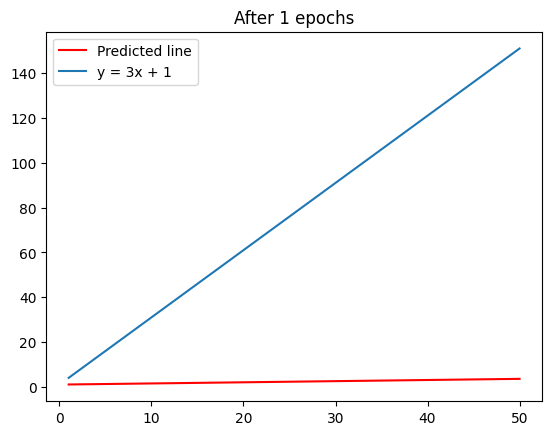

In [22]:
x = np.linspace(1, 50, 100)
y = (3 * x) + 1

def check(epochs):
    model = LinearRegression(x, y, epochs)
    values = model.train()
    
    gradient = values[0]
    intercept = values[1]
    
    new_x = np.linspace(1, 50, 100)
    new_y = (gradient * x) + intercept


    plt.plot(new_x, new_y, color = "red", label = "Predicted line")
    plt.plot(x, y, label = "y = 3x + 1")
    plt.legend()
    plt.title(f"After {epochs} epochs")
    plt.show()

check(1)

Initial weight: 0, initial bias 1
Final weight: 0.47491901336588066, final bias: 1.0141742914310474


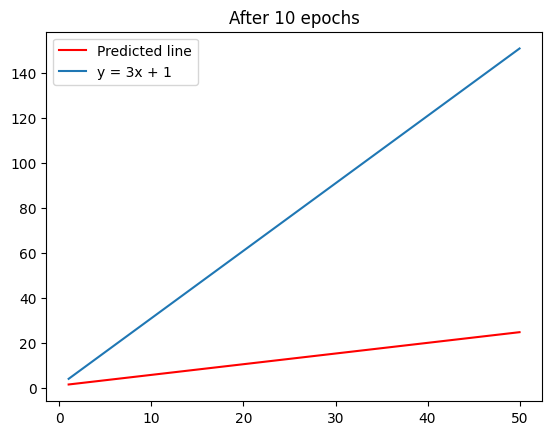

In [23]:
check(10)

Initial weight: 0, initial bias 1
Final weight: 2.463322647909349, final bias: 1.0734990231871018


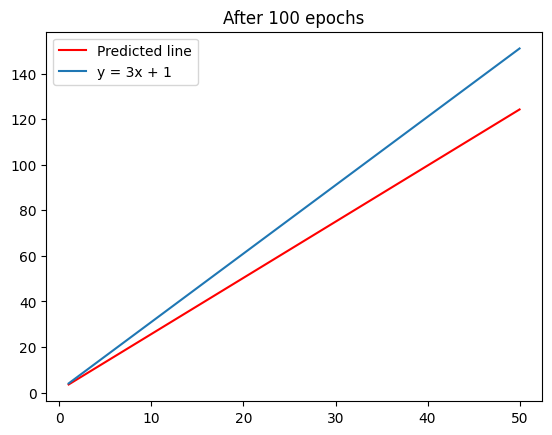

In [24]:
check(100)

Initial weight: 0, initial bias 1
Final weight: 2.9973410980521593, final bias: 1.089058165349528


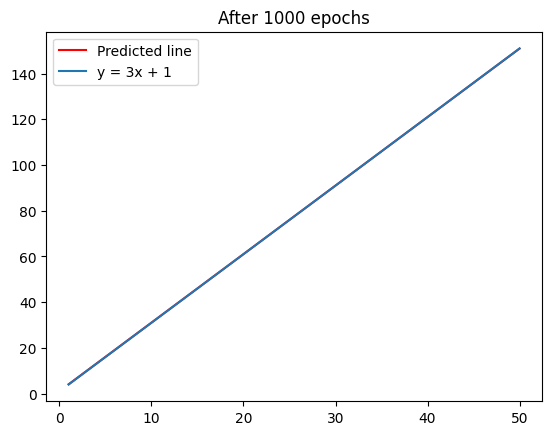

In [25]:
check(1000)

Initial weight: 0, initial bias 1
Final weight: 2.9974530160120514, final bias: 1.0853126485812028


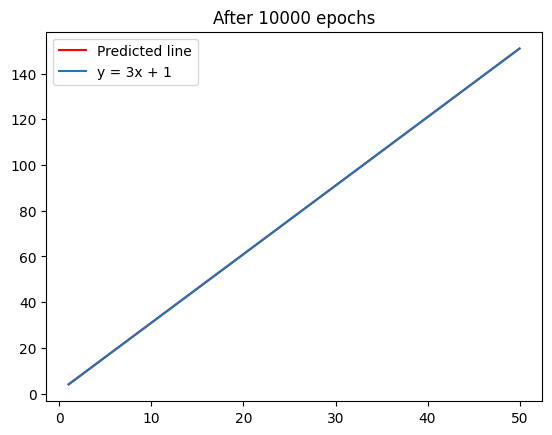

In [26]:
check(10000)

In [28]:
""" As the number of epochs increases, the improvement of the model depends more and more on the learning rate. A learning rate too large with a very large number of epochs actually worsens the model. 
What happens is the model keeps overshooting the improvement because of the larger learning rate, leading to it never actually making any improvements """
